# Deep fake classification with transfer learning: EfficientNet base

## Imports

In [1]:
#Graphics
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

#Keras
from keras.models import Model
from keras import Input, layers, optimizers, callbacks

from keras.utils import image_dataset_from_directory

#Pretrained model for transfer learning
from keras.applications.efficientnet import EfficientNetB3, preprocess_input

#Saving models
import joblib

2026-03-14 09:46:31.677781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773481591.888415      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773481591.946408      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773481592.421599      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773481592.421642      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773481592.421647      55 computation_placer.cc:177] computation placer alr

## Location of the data

In [2]:
#Lightweight dataset
train_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/"
val_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/"
test_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/"

## Parameters

In [15]:
BATCH_SIZE = 256
IMAGE_SIZE = (256, 256)
IMAGE_HEIGHT = IMAGE_SIZE[0]
IMAGE_WIDTH = IMAGE_SIZE[1]
NUM_CHANNELS = 3
SEED = 42
LEARNING_RATE = 0.001
PATIENCE = 5
EPOCHS = 40

## Creating datasets from directories

In [4]:
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)


val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 100000 files belonging to 2 classes.


I0000 00:00:1773481742.141745      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773481742.147875      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['fake', 'real']


In [16]:
def initialize_model(base_model):

    ######################
    ###  Architecture  ###
    ######################

    #Freezing weights of pretrained model
    base_model.trainable = False

    #Input
    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS))

    # x = data_augmentation(inputs)
    x = preprocess_input(inputs) #Preprocessing layer specifically designed for the pretrained model
    x = base_model(x) #Transfer learning model


    x = layers.Flatten()(x)

    #Dense layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy', 'recall', 'precision'])

    return model

In [17]:
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS))

In [18]:
model = initialize_model(base_model)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 98304)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    12,583,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,374,896 (89.17 MB)

 Trainable params: 12,591,361 (48.03 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [19]:
# MODEL = 'dfake_efficientnet.keras'

# modelCheckpoint = callbacks.ModelCheckpoint(MODEL,
#                                             monitor="val_loss",
#                                             verbose=0,
#                                             save_best_only=True)

LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

In [20]:
%%time
history = model.fit(train_ds,
                    epochs=EPOCHS,
                    validation_data=val_ds,
                    callbacks=[LRreducer, EarlyStopper],
                    verbose=1)

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 391s 915ms/step - accuracy: 0.7130 - loss: 0.9347 - precision: 0.6881 - recall: 0.7722 - val_accuracy: 0.8903 - val_loss: 0.2601 - val_precision: 0.9343 - val_recall: 0.8398 - learning_rate: 0.0010
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 318s 814ms/step - accuracy: 0.8625 - loss: 0.3235 - precision: 0.8401 - recall: 0.8946 - val_accuracy: 0.9169 - val_loss: 0.2076 - val_precision: 0.9627 - val_recall: 0.8675 - learning_rate: 0.0010
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 318s 813ms/step - accuracy: 0.8949 - loss: 0.2510 - precision: 0.8822 - recall: 0.9112 - val_accuracy: 0.9384 - val_loss: 0.1648 - val_precision: 0.9475 - val_recall: 0.9281 - learning_rate: 0.0010
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 319s 815ms/step - accuracy: 0.9092 - loss: 0.2179 - precision: 0.8948 - recall: 0.9270 - val_accuracy: 0.9365 - val_loss: 0.1581 - val_precision: 0.9728 - val_recall: 0.8980 - learning_rate: 0.0010
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 319s 816

In [21]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

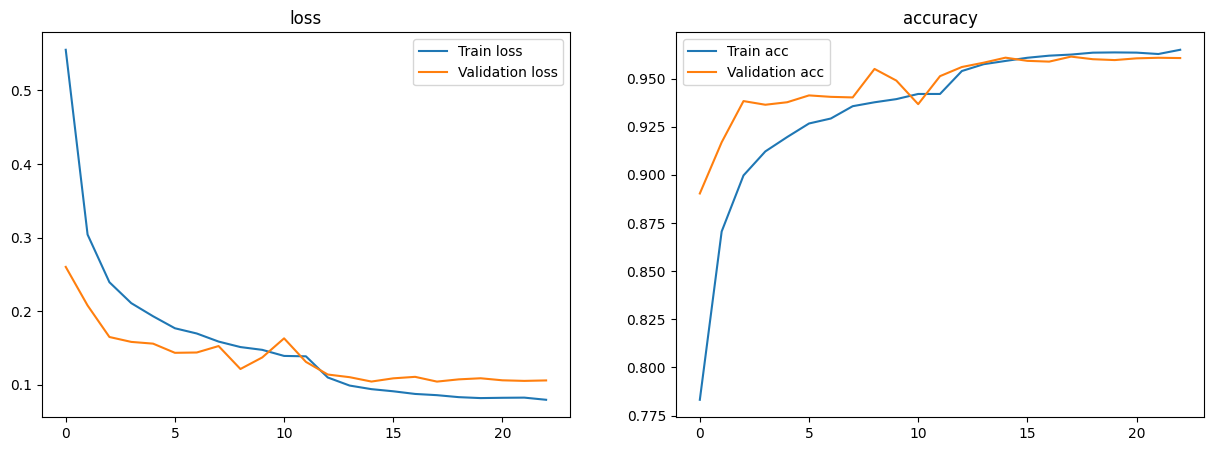

In [22]:
plot_history(history)

In [23]:
model.evaluate(test_ds)

79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 673ms/step - accuracy: 0.9610 - loss: 0.1076 - precision: 0.9767 - recall: 0.9442


[0.10901663452386856,
 0.9605000019073486,
 0.9430000185966492,
 0.9772020578384399]

In [24]:
joblib.dump(model, "/kaggle/working/efficientnet_full_dataset.joblib")

['/kaggle/working/efficientnet_full_dataset.joblib']